Feature scaling -->Min Max Normalization x(Scaled)=x(i)-x(min)/x(max)-x(min)

In [2]:
!pip install scikit-learn

In [3]:
#import the libraries
import numpy as np
import pandas as pd
import sklearn

In [4]:
data = pd.DataFrame({'Price_USA':[80,50,140,25],
                     'Price_INR' :[5000,7000,12000,3000]})
data

,Price_USA,Price_INR
0,80,5000
1,50,7000
2,140,12000
3,25,3000


In [5]:
#We will perform mathematical wise
data['Price_USA_minmax']=(data['Price_USA']-data['Price_USA'].min())/(data['Price_USA'].max()-data['Price_USA'].min())
data

,Price_USA,Price_INR,Price_USA_minmax
0,80,5000,0.478261
1,50,7000,0.217391
2,140,12000,1.000000
3,25,3000,0.000000


In [6]:
import sklearn

In [7]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [8]:
min_max=MinMaxScaler()

In [9]:
#we need to use fit_transform()
data['Price_USA_minsk']=min_max.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_USA_minsk
0,80,5000,0.478261,0.478261
1,50,7000,0.217391,0.217391
2,140,12000,1.000000,1.000000
3,25,3000,0.000000,0.000000


from sklearn.preprocessing import StandardScaler

In [10]:
scaler=StandardScaler()

In [11]:
data['Price_USA_scaler']=scaler.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_USA_minsk,Price_USA_scaler
0,80,5000,0.478261,0.478261,0.145617
1,50,7000,0.217391,0.217391,-0.553346
2,140,12000,1.000000,1.000000,1.543544
3,25,3000,0.000000,0.000000,-1.135815


In [12]:
data['Price_INR_scaler']=scaler.fit_transform(data[['Price_INR']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_USA_minsk,Price_USA_scaler,Price_INR_scaler
0,80,5000,0.478261,0.478261,0.145617,-0.523205
1,50,7000,0.217391,0.217391,-0.553346,0.074744
2,140,12000,1.000000,1.000000,1.543544,1.569614
3,25,3000,0.000000,0.000000,-1.135815,-1.121153


In [13]:
from sklearn.preprocessing import RobustScaler

In [14]:
robust=RobustScaler()

In [15]:
data['Price_USA_robust']=robust.fit_transform(data[['Price_USA']])
data['Price_USA_robust']

0    0.292683
1   -0.292683
2    1.463415
3   -0.780488
Name: Price_USA_robust, dtype: float64

In [16]:
data['Price_INR_robust']=robust.fit_transform(data[['Price_INR']])
data['Price_INR_robust']

0   -0.266667
1    0.266667
2    1.600000
3   -0.800000
Name: Price_INR_robust, dtype: float64

In [17]:
from sklearn.preprocessing import RobustScaler

In [18]:
robust=RobustScaler()

In [19]:
data['Price_USA_robust']=robust.fit_transform(data[['Price_USA']])
data['Price_USA_robust']

0    0.292683
1   -0.292683
2    1.463415
3   -0.780488
Name: Price_USA_robust, dtype: float64

In [20]:
data['Price_INR_robust']=robust.fit_transform(data[['Price_INR']])
data['Price_INR_robust']

0   -0.266667
1    0.266667
2    1.600000
3   -0.800000
Name: Price_INR_robust, dtype: float64

#Regression on Case Study related to predicting Miles per Gallo(mpg) #Scenarion as follows: A Fleet manager wanted to calculate(predict) the mpg efficiency of his vehicles based on(cylinder,weight,displacement,acceleration,horsepower)... Wewill be using UCIML repo package to fetch,load and transform the data from UCI repo

In [21]:
!pip install ucimlrepo

In [22]:
!pip install seaborn

In [30]:
#Step-1: Importing all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
sns.set_style(style='whitegrid') #background style of the graphs

In [33]:
#Step-2: Loading(autompg dataset)and Cleaning the data
data=fetch_ucirepo(id=9)
data
X=data.data.features.copy() #it returns all the numerical features
y=data.data.targets['mpg']
X
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [34]:
X.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.469388,2970.424623,15.568090,76.010050,1.572864
std,104.269838,1.701004,38.491160,846.841774,2.757689,3.697627,0.802055
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,104.250000,4.000000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,262.000000,8.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [35]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [36]:
X['origin'].unique();
X['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [37]:
#transforn hoursepower and origin coloumn
X['horsepower']=pd.to_numeric(X['horsepower'],errors='coerce')
X['origin']=X['origin'].astype(str)

In [38]:
X.info()
numerical_features=['cylinders','displacement','horsepower','weight','acceleration','model_year']
categorical_features=['origin']
X=X[numerical_features+categorical_features]
X.info()
X.isnull().sum()
X.shape

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    str    
dtypes: float64(3), int64(3), str(1)
memory usage: 22.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 n

(398, 7)

In [39]:
#Step-3: Quick Exploratory Data Analysis(Seaborn)
df=X.copy()
df['mpg']=y
df

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,8,307.0,130.0,3504,12.0,70,1,18.0
1,8,350.0,165.0,3693,11.5,70,1,15.0
2,8,318.0,150.0,3436,11.0,70,1,18.0
3,8,304.0,150.0,3433,12.0,70,1,16.0
4,8,302.0,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82,1,27.0
394,4,97.0,52.0,2130,24.6,82,2,44.0
395,4,135.0,84.0,2295,11.6,82,1,32.0
396,4,120.0,79.0,2625,18.6,82,1,28.0


Text(0.5, 1.0, 'Horsepower vs MPG Distribution')

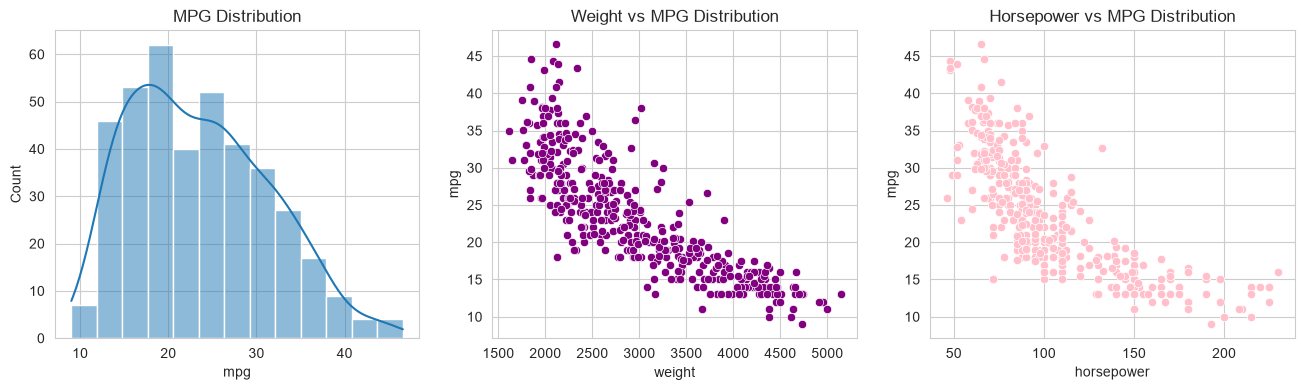

In [40]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
#plot graphs as per axes
sns.histplot(df['mpg'],kde=True,ax=axes[0])
#in similar way we display other graphs in rmng plots
axes[0].set_title("MPG Distribution")
sns.scatterplot(x=df['weight'],y=df['mpg'],ax=axes[1],color='purple')
axes[1].set_title("Weight vs MPG Distribution")
sns.scatterplot(x=df['horsepower'],y=df['mpg'],ax=axes[2],color='pink')
axes[2].set_title("Horsepower vs MPG Distribution")

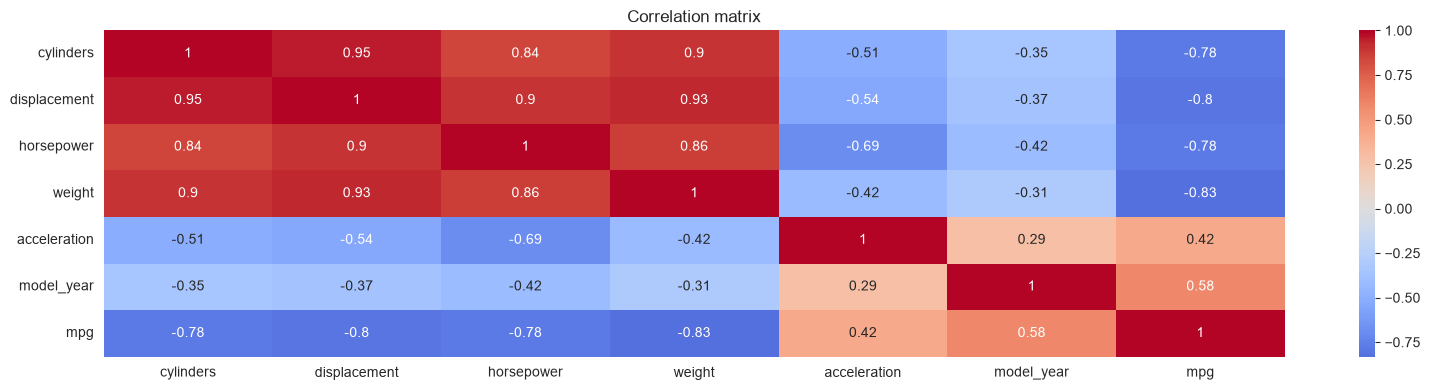

In [41]:
#Correlation between our variables
plt.figure(figsize=(16,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
           annot=True,
            cmap='coolwarm',
            center=0
           )
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

In [42]:
#Step-4: Dividing the data into train test split
print(X)
print(y)
X_train,X_test,y_train,y_test,=train_test_split(X,y,test_size=0.2,random_state=42)
print('\n Train test split')
print("Training Data",len(X_train))
print("Testing Data",len(X_test))

     cylinders  displacement  horsepower  weight  acceleration  model_year  \
0            8         307.0       130.0    3504          12.0          70   
1            8         350.0       165.0    3693          11.5          70   
2            8         318.0       150.0    3436          11.0          70   
3            8         304.0       150.0    3433          12.0          70   
4            8         302.0       140.0    3449          10.5          70   
..         ...           ...         ...     ...           ...         ...   
393          4         140.0        86.0    2790          15.6          82   
394          4          97.0        52.0    2130          24.6          82   
395          4         135.0        84.0    2295          11.6          82   
396          4         120.0        79.0    2625          18.6          82   
397          4         119.0        82.0    2720          19.4          82   

    origin  
0        1  
1        1  
2        1  
3        1 

In [43]:
#Step-5: Creating a baseline Model
def evaluate(model_name,actual,predicted):
    """Returns MAE,RMSE,R2-Score"""
    mse=mean_squared_error(actual,predicted)
    mae=mean_absolute_error(actual,predicted)
    return{'Model_Name':model_name,
    'MAE':mean_absolute_error,
    'MSE':mse,
    'RMSE':np.sqrt(mse),
    'R2-Score':r2_score(actual,predicted)}
results=[]

In [44]:
#Step-6: Baseline model --> It predicts the training set for every values
baseline_predictions=np.full(len(y_test),y_train.mean())
#baseline_predictions
#in above case we are keeping a baseline predictions
results.append(evaluate("Mean baseline",y_test,baseline_predictions))
results

[{'Model_Name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686}]

In [45]:
#Step-7: We apply Linear Regression
simple_model=LinearRegression()
#we fit the data to the model
simple_model.fit(X_train[['weight']],y_train)
simple_model_predictions=simple_model.predict(X_test[['weight']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:Weight",
                       y_test,
                       simple_model_predictions))
print(len(results))

2


In [46]:
#we will check the intercept value
print(f'Simple Linear Regression Equation')
print(f"Predicted MPG={simple_model.intercept_}+({simple_model.coef_[0]})*weight")

Simple Linear Regression Equation
Predicted MPG=46.78206336645047+(-0.007805242351594879)*weight


In [47]:
simple_model = LinearRegression()
#we fit the data the model
simple_model.fit(X_train[['cylinders']],y_train)
simple_model_prediction = simple_model.predict(X_test[['cylinders']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:cylinders",y_test,simple_model_prediction))
print(len(results))

3


In [48]:
simple_model = LinearRegression()
#we fit the data the model
simple_model.fit(X_train[['displacement']],y_train)
simple_model_prediction = simple_model.predict(X_test[['displacement']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:displacement",y_test,simple_model_prediction))
print(len(results))

4


Markdown:
X['horsepower'].fillna(X['horsepower'].mean(),inplace=True)

In [49]:
#Step-8: Multiple LinearRegerssion
#Multiple Regression uses one or more independent variables with a linear plane
#Polynomial Regression uses powers of a single variable to fit a curved line, though it is calculated using linear equations..
#We have missing numeric values in horsepower column we will fillit
#We have origin column which is catgory -->feature encoding
preprocessor=ColumnTransformer(transformers=[
    ("numbers",SimpleImputer(strategy="median"),
     numerical_features),
    ("category",Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),
                                ("encoder",OneHotEncoder(handle_unknown="ignore",
                                                         drop="first"),
                                )]),
     categorical_features),
]

                              )
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [50]:
multiple_model=Pipeline(
    steps=[("prepare",preprocessor),
           ("model",LinearRegression())]
)
multiple_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepare', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['cylinders','displacement','horsepower',...,'acceleration','model_year', 'origin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

In [51]:
multiple_predictions=multiple_model.predict(X_test)
results.append(evaluate("Multiple Regression",y_test,multiple_predictions))
results

[{'Model_Name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Simple Linear Regression:cylinders',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287},
 {'Model_Name': 'Simple Linear Regression:displacement',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true

In [70]:
#Step-9: Polynomial model
#it forms a curvilinear relationship
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
polynomial_model=Pipeline(
    steps=[("imputer",SimpleImputer(strategy="median")),
           ("polynomial",PolynomialFeatures(include_bias=False)),
           ("model",LinearRegression())])
#polynomial_model
#Selecting the polynomial degree
degree_search=GridSearchCV(
    polynomial_model,
    param_grid={'polynomial__degree':[1,2,3,4,5]},
    scoring="neg_mean_squared_error",
    cv=5)

In [71]:
degree_search.fit(X_train[['horsepower']], y_train)
polynomial_predictions = degree_search.predict(X_test[['horsepower']])
results.append(evaluate("Polynomial: Horsepower",
                        y_test, polynomial_predictions))
results

[{'Model_Name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Simple Linear Regression:cylinders',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287},
 {'Model_Name': 'Simple Linear Regression:displacement',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true

In [72]:
#findout the best degree (GridSearch CrossValidation
best_degree=degree_search.best_params_['polynomial__degree']
cv_rmse=np.sqrt(-degree_search.best_score_)
print(best_degree)
print(cv_rmse)

2
4.620314169891041


In [73]:
#finally we will print the results
results=pd.DataFrame(results).sort_values("RMSE")
results

,Model_Name,MAE,MSE,RMSE,R2-Score
4,Multiple Regression,<function mean_absolute_error at 0x0000021E501...,8.338668,2.887675,0.844909
5,Polynomial: Horsepower,<function mean_absolute_error at 0x0000021E501...,13.978713,3.738812,0.740010
1,Simple Linear Regression:Weight,<function mean_absolute_error at 0x0000021E501...,14.894861,3.859386,0.722971
3,Simple Linear Regression:displacement,<function mean_absolute_error at 0x0000021E501...,18.102544,4.254708,0.663311
2,Simple Linear Regression:cylinders,<function mean_absolute_error at 0x0000021E501...,19.664864,4.434508,0.634254
0,Mean baseline,<function mean_absolute_error at 0x0000021E501...,53.983298,7.347333,-0.004033
